边缘线条描绘（猫毛展示）

In [ ]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', cv2.IMREAD_GRAYSCALE)

# 应用 Canny 边缘检测（线条描绘）
# 高低阀值（不懂）
edges = cv2.Canny(image, 100, 100)
# edges = cv2.Canny(image, 50, 150, apertureSize=3, L2gradient=False)

# 显示结果
cv2.imshow('mimi-cat', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

黑白渲染程度

In [70]:
import cv2
import numpy as np

# 读取图像
img = cv2.imread('mimi.jpg')

# 简单阈值处理
# 数字1猫猫黑色程度（正比） 数字2背景白度数（正比）
ret, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 显示结果
cv2.imshow('Binary Threshold', thresh1)
cv2.waitKey(0)
cv2.destroyAllWindows()

高斯模糊值

In [95]:
import cv2

# 读取图像
image = cv2.imread('mimi.jpg')

# 应用高斯滤波    （A， B）， C ---> AB模糊值，越大越模糊  C高斯标准方差
blurred_image = cv2.GaussianBlur(image, (15, 15), 0)

# 显示结果
cv2.imshow('Gaussian Blurred Image', blurred_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

图像模糊程度

In [39]:
import cv2

# 读取图像
image = cv2.imread('mimi.jpg')

# 应用均值滤波  --->  值越高就越模糊  （横向、纵向）
# 左小右打（跳跃）  右小左大（跑步）  都大（模糊）
blurred_image = cv2.blur(image, (1, 100))

# 显示结果
cv2.imshow('Blurred Image', blurred_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

两图片各各坐标像素点相加 如果两个值相加超过255则取255

In [75]:
import cv2
import numpy as np

# 读取两幅图像
img1 = cv2.imread('wangwang.jpg')
img2 = cv2.imread('mimi.jpg')

# 取两张图各自维度的最小值（不裁剪）
h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
img1 = cv2.resize(img1, (w, h))
img2 = cv2.resize(img2, (w, h))

# 图像加法(图片尺寸不一样会报错)
result = cv2.add(img1, img2)

# 显示结果
cv2.imshow('Result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

两图片各各坐标像素点相减法 如果两个值相减法低于0则取0

In [76]:
# 图像减法
result = cv2.subtract(img1, img2)

# 取两张图各自维度的最小值（不裁剪）
h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
img1 = cv2.resize(img1, (w, h))
img2 = cv2.resize(img2, (w, h))

# 显示结果
cv2.imshow('Result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

两图片各各坐标像素点相乘 如果两个值相乘超过255则取255

In [77]:
# 图像乘法
result = cv2.multiply(img1, img2)


# 取两张图各自维度的最小值（不裁剪）
h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
img1 = cv2.resize(img1, (w, h))
img2 = cv2.resize(img2, (w, h))

# 显示结果
cv2.imshow('Result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

两图片各各坐标像素点相除法 如果两个值相除低于0取0

In [78]:
# 图像除法
result = cv2.divide(img1, img2)


# 取两张图各自维度的最小值（不裁剪）
h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
img1 = cv2.resize(img1, (w, h))
img2 = cv2.resize(img2, (w, h))

# 显示结果
cv2.imshow('Result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

同理
cv2.bitwise_or(img1, img2)   位或运算 (OR) 
cv2.bitwise_not(img1)        位非运算 (NOT)
bitwise_xor(img1, img2)      位异或运算 (XOR)

可以选取图片比重进行混合   公式：result = img1 * alpha + img2 * beta + gamma

In [86]:
# 图像混合
alpha = 0.3  # 第一幅图像的权重
beta = 0.7   # 第二幅图像的权重
gamma = 0    # 可选的标量值

result = cv2.addWeighted(img1, alpha, img2, beta, gamma)

# 显示结果
cv2.imshow('Result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

图像边缘化（线条）

In [108]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', cv2.IMREAD_GRAYSCALE)

# 计算 x 方向的梯度
# 列方向白线粗
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)

# 计算 y 方向的梯度
# 横方向白线粗
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# 1, 1 白色线条都细

# 计算梯度幅值
# 都粗
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)

# 显示结果
cv2.imshow('Sobel X', sobel_x)
cv2.imshow('Sobel Y', sobel_y)
cv2.imshow('Sobel Combined', sobel_combined)
cv2.waitKey(0)
cv2.destroyAllWindows()

边缘（线条）Laplacian 算子

In [110]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', cv2.IMREAD_GRAYSCALE)

# 应用 Laplacian 算子
laplacian = cv2.Laplacian(image, cv2.CV_64F)

# 显示结果
cv2.imshow('Laplacian', laplacian)
cv2.waitKey(0)
cv2.destroyAllWindows()

图像直立方图（参数不懂） vs  直立图比较

cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])
channels: 需要计算直方图的通道索引。对于灰度图像，使用 [0]；对于彩色图像，可以使用 [0]、[1]、[2] 分别计算蓝色、绿色和红色通道的直方图。  (似乎懂)
mask: 掩码图像。如果指定了掩码，则只计算掩码区域内的像素。如果不需要掩码，可以传入 None。  （不理解） 
histSize: 直方图的 bin 数量。对于灰度图像，通常设置为 [256]，表示将灰度级分为 256 个 bin。
ranges: 像素值的范围。对于灰度图像，通常设置为 [0, 256]，表示像素值的范围是 0 到 255。 //值小会影响高度


hist: 输出的直方图数组。
accumulate: 是否累积直方图。如果设置为 True，则直方图不会被清零，而是在每次调用时累积。

Histogram Similarity: -0.13090180390869366


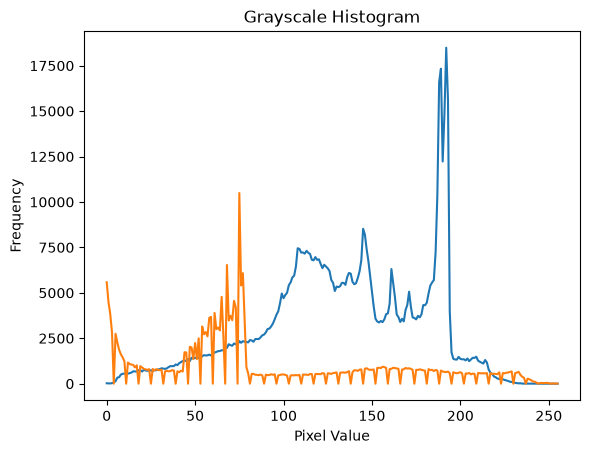

In [151]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
# img = cv2.imread('mimi.jpg', cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread('mimi.jpg')
img2 = cv2.imread('wangwang.jpg')

# 计算直方图
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

# 比较直方图（不同）
similarity = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
print("Histogram Similarity:", similarity)

# 绘制直方图
plt.plot(hist1)  #直线
plt.plot(hist2)  #直线
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

直方图均衡化

In [122]:
# 直方图均衡化
equalized_image = cv2.equalizeHist(image)

# 显示结果
cv2.imshow("Equalized Image", equalized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

彩图均匀化

In [123]:
# 分离通道

image1 = cv2.imread('cat.jpg')
b, g, r = cv2.split(image1)

# 对每个通道进行直方图均衡化
b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

# 合并通道
equalized_image = cv2.merge([b_eq, g_eq, r_eq])

# 显示结果
cv2.imshow("Equalized Color Image", equalized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

每个像素点变大变黑（mc） --->腐蚀

In [142]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', 0)

# 定义结构元素
# 第一个是纵向（正比）， 第二个是横向（正比）
kernel = np.ones((4,20), np.uint8)

# 腐蚀操作
eroded_image = cv2.erode(image, kernel, iterations=1)

# 显示结果
cv2.imshow('Eroded Image', eroded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

每个像素点变大变白（mc）--->膨胀

In [138]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', 0)

# 定义结构元素
# 第一个是纵向（正比）， 第二个是横向（正比）
kernel = np.ones((10,30), np.uint8)

# 膨胀操作
dilated_image = cv2.dilate(image, kernel, iterations=1)

# 显示结果
cv2.imshow('Dilated Image', dilated_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

原理是上述2个先后变化 --->腐蚀 + 膨胀

In [144]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', 0)

# 定义结构元素
# 第一个是纵向（正比）， 第二个是横向（正比）
kernel = np.ones((5,45), np.uint8)

# 开运算
opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

# 显示结果
cv2.imshow('Opened Image', opened_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

依旧像素咪咪与膨胀相似   ---> 形态学梯度 

In [148]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('mimi.jpg', 0)

# 定义结构元素
kernel = np.ones((15,15), np.uint8)

# 闭运算
closed_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# 显示结果
cv2.imshow('Closed Image', closed_image)
cv2.waitKey(0)
cv2.destroyAllWindows()